# Steamroller 🚧
### Borrow cheap money, lend it where rates are high, pocket the gap. What could go wrong?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Crash risk?: Severe](https://img.shields.io/badge/Crash_risk%3F-Severe-8b949e?style=flat-square)

The **carry trade** is the oldest game in global macro: borrow a currency with low interest rates (yen, francs), convert to one with high rates (Aussie dollars, reais), and earn the difference. Uncovered interest-rate parity says the high-rate currency *should* depreciate just enough to cancel your edge — but empirically it doesn't, so the carry is a real, paid premium. It also has a nickname among the people who run it: *picking up nickels in front of a steamroller.*

This is the desk's tenth idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §8.2). We prove the engine on a synthetic G10 where the premium and its crashes are baked in (and a null where parity holds), measure the verdict on the **real G10 tape** (OECD short rates + FX, 2001–2024), and explain why the carry crash is the one tail the desk's usual risk overlay can't dodge.

> 📓 **Plain-language layer.** The premium *t*-stat, the negative-skew crash and the vol-management test are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the executed cells run on the **synthetic** control (the machinery proof), and every real-tape number is quoted from [`../docs/results.md`](../docs/results.md) (270 months 2001–2024, as-of 2024-01-31, fingerprint `ef7450ae792e`, the same shared G10 cache as [Study 36](../../36-greenback/)). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from steamroller import data, carry, strategy, decompose, extension

# Offline synthetic G10: a CARRY PREMIUM tape (high-rate currencies out-earn, punctuated by sticky
# risk-off crashes) and a full-UIRP NULL. The real G10 verdict (OECD rates + FX, 2001-2024, shared
# with Study 36) is quoted from ../docs/results.md.
xr,  rates,  truth = data.synthetic_carry(carry_strength=0.9, seed=27)   # the carry-premium tape
xr0, rates0, _     = data.synthetic_carry(carry_strength=0.0, seed=27)   # the full-UIRP null
print(f"{truth.n_ccy} currencies x {truth.n_months} months | baked carry_strength={truth.carry_strength} | null=0")


9 currencies x 600 months | baked carry_strength=0.9 | null=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Do high-rate currencies out-earn? | 🟡 **Yes, but thinly** — on the real 2001–2024 G10 the bucket spread is **+2.8%/yr** and the carry book earns **+0.8%/yr** at *t* **+0.9** — the right slope, but this sample alone can't reject zero. (The synthetic control proves the machine: **+2.1%/yr**, *t* **+2.8**.) |
| What's the catch? | 🚧 **The steamroller** — a sharply negative-skewed return (real tape **−0.90**) with the crash arriving all at once: worst month **−5.8%**, October 2008. |
| Can you risk-manage the crash? | ⚪ **No** — on the real tape vol-targeting *cuts* the Sharpe (+0.20 → +0.11) and *deepens* the drawdown (−15% → −26%); the crash is a sudden jump, not a vol build-up you can see coming. |

> Desk shorthand: **Signal `WEAK` · Tradability `FRAGILE` · Crash risk? `SEVERE`** — a thin premium that is compensation for a tail you must be willing to hold through.

## 1 · The claim 📣

Rank currencies by their short interest rate **as of the prior month-end** (no peeking at the month you're earning); the high-rate ones earn more, because they don't depreciate enough to offset the yield (UIRP fails). On our synthetic G10, sort into buckets and read the average excess return — a clean upward slope:

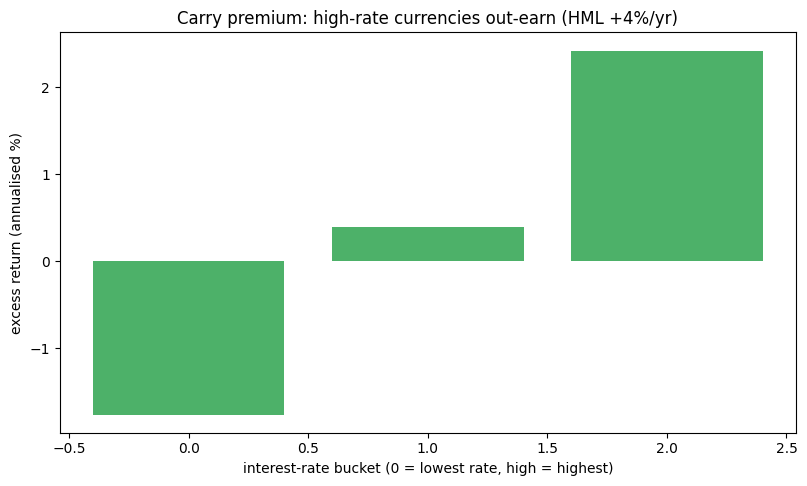

Real G10 tape (../docs/results.md): HML bucket spread +2.8%/yr -- same slope, thinner.


In [2]:
pb = carry.carry_premium_by_bucket(xr, rates)   # buckets sorted on the LAGGED rate
b = pb['bucket_ann_pct']
fig, ax = plt.subplots(); ax.bar(b.index, b.values, color='#2ea44f', alpha=.85)
ax.set_xlabel('interest-rate bucket (0 = lowest rate, high = highest)'); ax.set_ylabel('excess return (annualised %)')
ax.set_title(f"Carry premium: high-rate currencies out-earn (HML {pb['hml_ann_pct']:+.0f}%/yr)")
plt.show()
print('Real G10 tape (../docs/results.md): HML bucket spread +2.8%/yr -- same slope, thinner.')

## 2 · So what? 💰

Carry is a cornerstone of global-macro and currency funds — a steady, diversifying, self-financed return stream. But the steady drip is the trap: the premium is *compensation* for a rare disaster. When global risk appetite collapses, everyone unwinds the same carry positions at once, the funding currencies spike, the high-yielders crater, and the trade loses years of gains in weeks. The whole question is whether the nickels are worth the steamroller.

## 3 · How we'd know 🔬

Three checks:

1. **Is the premium real?** The carry portfolio's return and Newey-West *t* — on the real G10 tape, with the synthetic control and its full-UIRP null proving the machine.
2. **How bad is the tail?** The skew, worst months and drawdown.
3. **Can it be managed?** Vol-scaling the book.

**The lines, announced:** `REAL` needs the real-tape *t* above 2; a positive premium that can't reject zero is `WEAK`; and the crash is `SEVERE` if the vol overlay fails to shrink it.

## 4 · The teardown 🔧

### 4a · The premium, and the null
Run the carry book on both synthetic tapes (the carry premium, and the full-UIRP null) — then read the same numbers off the real G10.

In [3]:
for label, (x, rt) in [('carry premium', (xr, rates)), ('UIRP null', (xr0, rates0))]:
    cmp = strategy.compare(x, rt, cost_bps=10.0); pt = decompose.premium_tstat(x, rt, cost_bps=10.0)
    print(f"{label:14s}: Sharpe {cmp['sharpe']:+.2f}, premium {pt['mean_ann_pct']:+.1f}%/yr "
          f"(HAC t {pt['t_stat']:+.1f}), turnover {cmp['turnover_ann']:.1f}x/yr")
print()
print('Real G10, 2001-2024 (../docs/results.md): Sharpe +0.22, premium +0.8%/yr '
      '(HAC t +0.9), turnover 0.55x/yr -- positive, thin, cannot reject zero.')
# note the synthetic turnover: the control's rates are CONSTANT per currency, so its book
# never rebalances (0.0x/yr) -- the cost story is only truly exercised on the real tape.

carry premium : Sharpe +0.60, premium +2.1%/yr (HAC t +2.8), turnover 0.0x/yr
UIRP null     : Sharpe -0.03, premium -0.1%/yr (HAC t -0.2), turnover 0.0x/yr

Real G10, 2001-2024 (../docs/results.md): Sharpe +0.22, premium +0.8%/yr (HAC t +0.9), turnover 0.55x/yr -- positive, thin, cannot reject zero.


### 4b · The steamroller — carry's fat tail
The cumulative return and its drawdown: a steady climb, then a cliff.

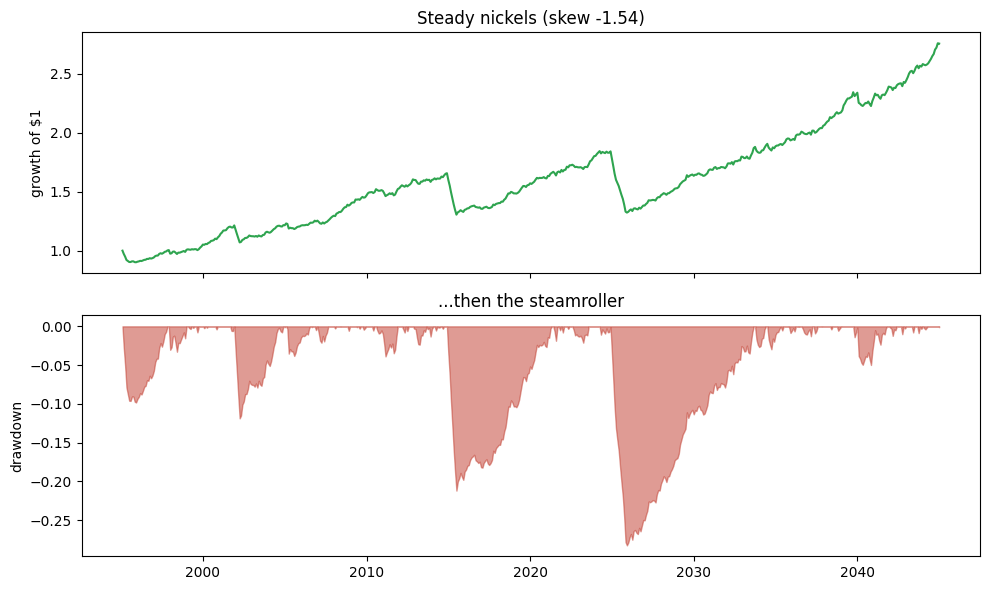

synthetic: skew -1.54, worst month -4.3%, max drawdown -28%
real G10 : skew −0.90, worst month −5.8% (Oct 2008), max drawdown −15% -- the 2008 and 2020 risk-offs, exactly where the story puts them (../docs/results.md).


In [4]:
r = strategy.carry_returns(xr, rates, cost_bps=10.0)
eq = (1+r).cumprod(); dd = eq/eq.cummax()-1
cr = decompose.crash_profile(xr, rates, cost_bps=10.0)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
a1.plot(eq.index, eq.values, color='#2ea44f'); a1.set_ylabel('growth of $1'); a1.set_title(f'Steady nickels (skew {cr["skew"]:+.2f})')
a2.fill_between(dd.index, dd.values, 0, color='#c0392b', alpha=.5); a2.set_ylabel('drawdown'); a2.set_title('...then the steamroller')
plt.tight_layout(); plt.show()
print(f"synthetic: skew {cr['skew']:+.2f}, worst month {cr['worst_month_pct']:+.1f}%, max drawdown {cr['max_drawdown_pct']:.0f}%")
print('real G10 : skew −0.90, worst month −5.8% (Oct 2008), max drawdown −15% '
      '-- the 2008 and 2020 risk-offs, exactly where the story puts them (../docs/results.md).')

### 4c · The crash resists risk management
Vol-targeting tamed the crash for equity ([Study 16](../../16-storm-shy/)) and momentum ([Study 24](../../24-stampede/)). Try it on carry:

In [5]:
cc = extension.crash_comparison(xr, rates, cost_bps=10.0)
for k in ['plain', 'managed']:
    p = cc[k]; print(f"{k:8s}: Sharpe {p['sharpe']:+.2f}, skew {p['skew']:+.2f}, max drawdown {p['max_drawdown_pct']:.0f}%")
print('on the synthetic, vol-targeting lifts the Sharpe but does NOT shrink the drawdown.')
print('on the REAL tape it is a strict loss: Sharpe +0.20 -> +0.11, '
      'drawdown −15% -> −26% (../docs/results.md) -- it levers INTO the jump.')

plain   : Sharpe +0.68, skew -1.57, max drawdown -28%
managed : Sharpe +0.95, skew -1.01, max drawdown -44%
on the synthetic, vol-targeting lifts the Sharpe but does NOT shrink the drawdown.
on the REAL tape it is a strict loss: Sharpe +0.20 -> +0.11, drawdown −15% -> −26% (../docs/results.md) -- it levers INTO the jump.


## 5 · The verdict 🧾

- **A thin, real-shaped premium** — +0.8%/yr at *t* +0.9 on the real 2001–2024 tape (bucket spread +2.8%/yr); the control proves the machine (+2.1%/yr, *t* +2.8; null flat). Positive, but this sample can't reject zero → `WEAK`.
- **Severe tail** — real skew −0.90, worst month −5.8% (Oct 2008), drawdown −15% on a 3.6%-vol book.
- **Hard to hedge** — on the real tape vol-targeting cuts the Sharpe *and* deepens the drawdown.

> **Signal `WEAK` · Tradability `FRAGILE` · Crash risk? `SEVERE`.** The premium is rent paid for standing in front of the steamroller.

## 6 · Could you trade it? 💸

- **It is genuinely cheap to run** — real turnover 0.55×/yr; even a punitive 100 bp per unit traded leaves the Sharpe positive (+0.08). Cost is not what kills carry.
- **But the edge is thin** (+0.8%/yr, Sharpe +0.22) **and the drawdown ends books** — a crash hitting every leg at once, every cycle, is a career risk, not a line-item.
- **And the usual hedge fails** — vol-targeting can't forecast a jump; on the real tape it made both the Sharpe and the tail worse. The honest defences are diversification ([Study 36](../../36-greenback/) measures exactly that), options, or a risk-off switch.

> Tradability **`FRAGILE`**; crash **`SEVERE`** — the worked complement ([`../docs/extension.md`](../docs/extension.md)) shows why the vol overlay doesn't save you.

## 7 · Going further 🚪

- **Why vol-targeting fails** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): the crash is a jump; trailing vol can even *lever you into* it — and on the real tape, did.
- **Diversification instead of an overlay** — [Study 36 (Greenback)](../../36-greenback/) runs the carry⊕momentum combo on this same tape: it cushions the crash, but can't lift the Sharpe while FX momentum is losing.
- **Real tail hedges.** Options-based downside, a risk-off conditioning switch (VIX / drawdown control) — which actually shrinks the tail without killing the premium?
- **The pre-2000 sample.** Our rates tape starts in 2001; the fat carry decades (80s–90s) are out of reach of this source. A longer tape (e.g. forward points) could move `WEAK` back toward `REAL`.

PRs welcome — extend the tape, or build a tail hedge that earns its keep.